# Environment Setup & Library Imports

In [ ]:
# Installing necessary libraries for the environment
!pip install xgboost scikit-learn pandas numpy joblib matplotlib seaborn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import json
import os

# Machine Learning & Preprocessing
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Configurations
warnings.filterwarnings('ignore')
%matplotlib inline

print("Environment ready and libraries imported.")

Environment ready and libraries imported.


# Dataset Acquisition & Google Drive Integration

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Dataset Path
# Note: Ensure the 'paysim_data.csv' is present in your Drive's root or specified folder
file_path = "/content/drive/MyDrive/paysim_data.csv"

if os.path.exists(file_path):
    # 3. Load Dataset
    df = pd.read_csv(file_path)

    # 4. Display Basic Info
    print(f" Dataset loaded successfully!")
    print(f"Total Rows: {len(df):,}")
    print(f"Total Columns: {df.shape[1]}")
    print("-" * 30)
    print(df.head())
else:
    print(f" Error: File not found at {file_path}. Please check the path.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset loaded successfully!
Total Rows: 6,362,620
Total Columns: 11
------------------------------
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         

# Data Cleaning & Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

# 1. Feature Selection: Removing Leaky and Irrelevant Columns
# We remove 'newbalanceOrig' and 'newbalanceDest' to prevent Data Leakage
# (these values are updated AFTER the transaction occurs).
# Unique IDs are also removed to prevent overfitting.
leaky_columns = ['nameOrig', 'nameDest', 'newbalanceOrig', 'newbalanceDest', 'isFlaggedFraud']
df_cleaned = df.drop(columns=[col for col in leaky_columns if col in df.columns])

# 2. Feature Engineering: Cyclic Time Analysis (Hour of Day)
# The 'step' column represents hours from the start of simulation.
# Converting this to a 24-hour cycle helps identify suspicious timing patterns.
df_cleaned['hour'] = df_cleaned['step'] % 24

# 3. Feature Engineering: Financial Ratios
# High-risk transactions often involve draining the entire account balance.
df_cleaned['amount_to_balance_ratio'] = df_cleaned['amount'] / (df_cleaned['oldbalanceOrg'] + 1)

# 4. Feature Engineering: Transaction Logic (Overdraft Check)
# Identifies if the transaction amount exceeds the available original balance.
df_cleaned['is_overdraft'] = (df_cleaned['amount'] > df_cleaned['oldbalanceOrg']).astype(int)

# 5. Summary of Preprocessing
print("-" * 50)
print("SUCCESS: Data Cleaning & Engineering Complete")
print("-" * 50)
print(f"Final Feature Columns: {list(df_cleaned.columns)}")
print(f"Engineered Features: ['hour', 'amount_to_balance_ratio', 'is_overdraft']")
print("-" * 50)

df_cleaned.head()

--------------------------------------------------
SUCCESS: Data Cleaning & Engineering Complete
--------------------------------------------------
Final Feature Columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'isFraud', 'hour', 'amount_to_balance_ratio', 'is_overdraft']
Engineered Features: ['hour', 'amount_to_balance_ratio', 'is_overdraft']
--------------------------------------------------


,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,hour,amount_to_balance_ratio,is_overdraft
0,1,PAYMENT,9839.64,170136.0,0.0,0,1,0.057834,0
1,1,PAYMENT,1864.28,21249.0,0.0,0,1,0.087731,0
2,1,TRANSFER,181.00,181.0,0.0,1,1,0.994505,0
3,1,CASH_OUT,181.00,181.0,21182.0,1,1,0.994505,0
4,1,PAYMENT,11668.14,41554.0,0.0,0,1,0.280788,0


# Label Encoding & Feature Serialization

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib
import json

# 1. Initialize and Fit LabelEncoder
# This converts transaction types (PAYMENT, TRANSFER, etc.) into integers
label_encoder = LabelEncoder()
df_cleaned['type'] = label_encoder.fit_transform(df_cleaned['type'])

# 2. Define Final Features (Optimized)
# Removed 'step' to prevent overfitting; 'hour' provides the necessary time context.
FEATURES = [
    'type',
    'amount',
    'oldbalanceOrg',
    'oldbalanceDest',
    'hour',
    'amount_to_balance_ratio',
    'is_overdraft'
]

X = df_cleaned[FEATURES]
y = df_cleaned['isFraud']

# 3. Save Artifacts for Deployment
# These files are crucial for your Flask/Django backend to process new inputs
joblib.dump(label_encoder, 'fintech_label_encoder.pkl')

with open('fintech_features.json', 'w') as f:
    json.dump(FEATURES, f)

print("-" * 50)
print("SUCCESS: Encoding and Feature Selection Complete")
print("-" * 50)
print(f"Encoded Classes: {list(label_encoder.classes_)}")
print(f"Final Feature Set: {FEATURES}")
print("-" * 50)

X.head()

--------------------------------------------------
SUCCESS: Encoding and Feature Selection Complete
--------------------------------------------------
Encoded Classes: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Final Feature Set: ['type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'hour', 'amount_to_balance_ratio', 'is_overdraft']
--------------------------------------------------


,type,amount,oldbalanceOrg,oldbalanceDest,hour,amount_to_balance_ratio,is_overdraft
0,3,9839.64,170136.0,0.0,1,0.057834,0
1,3,1864.28,21249.0,0.0,1,0.087731,0
2,4,181.00,181.0,0.0,1,0.994505,0
3,1,181.00,181.0,21182.0,1,0.994505,0
4,3,11668.14,41554.0,0.0,1,0.280788,0


# Data Splitting, Scaling, and Handling Class Imbalance (SMOTE)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

# 1. Train-Test Split (80/20)
# 'stratify=y' ensures that both sets have the same percentage of fraud cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Feature Scaling
# Standardizing features so they have a mean of 0 and variance of 1.
# This is crucial for stable training when using multiple engineered features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Handling Class Imbalance with SMOTE
# SMOTE is only applied to the TRAINING data to prevent 'Data Leakage' into the test set.
print("Original Class Distribution (Train):", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Balanced Class Distribution (After SMOTE):", y_train_res.value_counts().to_dict())

# 4. Save Scaler for Deployment
# The backend will use this file to process real-time user inputs.
joblib.dump(scaler, 'fintech_scaler.pkl')

print("-" * 50)
print("SUCCESS: Data Splitting, Scaling, and Oversampling Complete")
print("Artifact Saved: 'fintech_scaler.pkl'")
print("-" * 50)

Original Class Distribution (Train): {0: 5083526, 1: 6570}
Balanced Class Distribution (After SMOTE): {0: 5083526, 1: 5083526}
--------------------------------------------------
SUCCESS: Data Splitting, Scaling, and Oversampling Complete
Artifact Saved: 'fintech_scaler.pkl'
--------------------------------------------------


# Model Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Train XGBoost Model (CPU Version)
print("Training XGBoost Model on CPU (This may take 5-10 minutes)...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',   # Keep 'hist' for efficiency even on CPU
    device='cpu',         # Force CPU usage
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)
xgb_model.fit(X_train_res, y_train_res)

# 2. Train Random Forest Model
print("Training Random Forest Model...")
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

# 3. Model Serialization
joblib.dump(xgb_model, 'fintech_xgb_model.pkl')
joblib.dump(rf_model, 'fintech_rf_model.pkl')

print("-" * 50)
print("SUCCESS: Model Training Complete on CPU")
print("-" * 50)
print("Artifacts Saved: 'fintech_xgb_model.pkl', 'fintech_rf_model.pkl'")
print("-" * 50)

Training XGBoost Model on CPU (This may take 5-10 minutes)...
Training Random Forest Model...
--------------------------------------------------
SUCCESS: Model Training Complete on CPU
--------------------------------------------------
Artifacts Saved: 'fintech_xgb_model.pkl', 'fintech_rf_model.pkl'
--------------------------------------------------


# Model Evaluation & Performance Benchmarking


========================= XGBoost (Optimized) Evaluation =========================


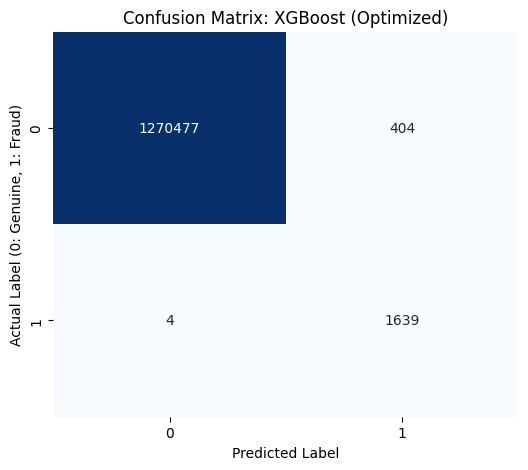


Classification Report for XGBoost (Optimized):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.80      1.00      0.89      1643

    accuracy                           1.00   1272524
   macro avg       0.90      1.00      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9994

========================= Random Forest Evaluation =========================


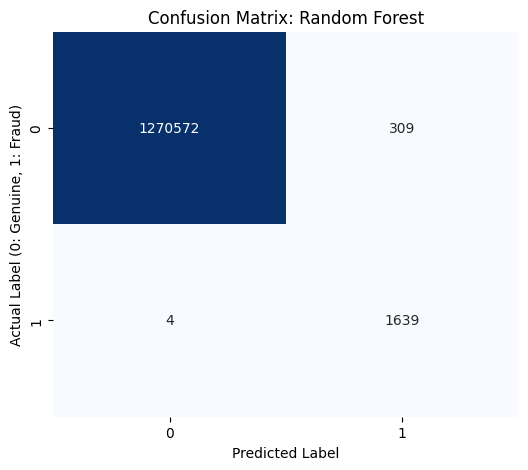


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.84      1.00      0.91      1643

    accuracy                           1.00   1272524
   macro avg       0.92      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9993


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_performance(model, X_val, y_val, model_name="Model"):
    """
    Function to visualize the confusion matrix and print detailed metrics
    for fraud detection performance.
    """
    print(f"\n{'='*25} {model_name} Evaluation {'='*25}")

    # 1. Generate Predictions & Probabilities
    y_pred = model.predict(X_val)
    y_probs = model.predict_proba(X_val)[:, 1]

    # 2. Visualization: Confusion Matrix
    # This shows exactly how many False Positives and False Negatives the model generated.
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label (0: Genuine, 1: Fraud)')
    plt.xlabel('Predicted Label')
    plt.show()

    # 3. Detailed Classification Metrics
    # Precision, Recall, and F1-Score are vital for imbalanced data.
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_val, y_pred))

    # 4. Statistical Metric: ROC-AUC
    # Measures the model's ability to distinguish between classes.
    auc_score = roc_auc_score(y_val, y_probs)
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print("=" * 65)

# --- Execute Evaluation for Both Models ---

# Evaluating XGBoost Performance
evaluate_performance(xgb_model, X_test_scaled, y_test, "XGBoost (Optimized)")

# Evaluating Random Forest Performance
evaluate_performance(rf_model, X_test_scaled, y_test, "Random Forest")

# Feature Importance Visualization

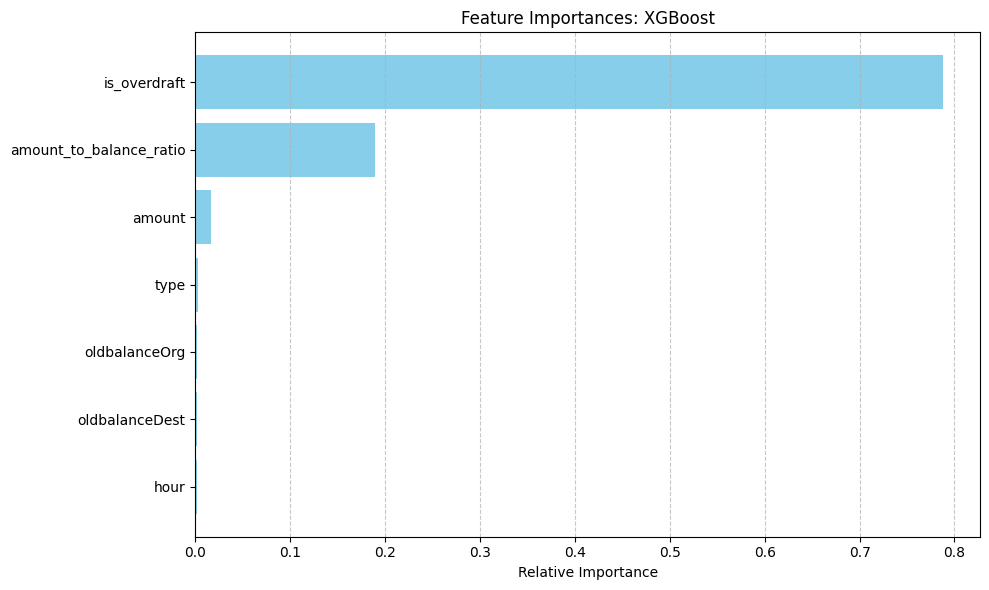

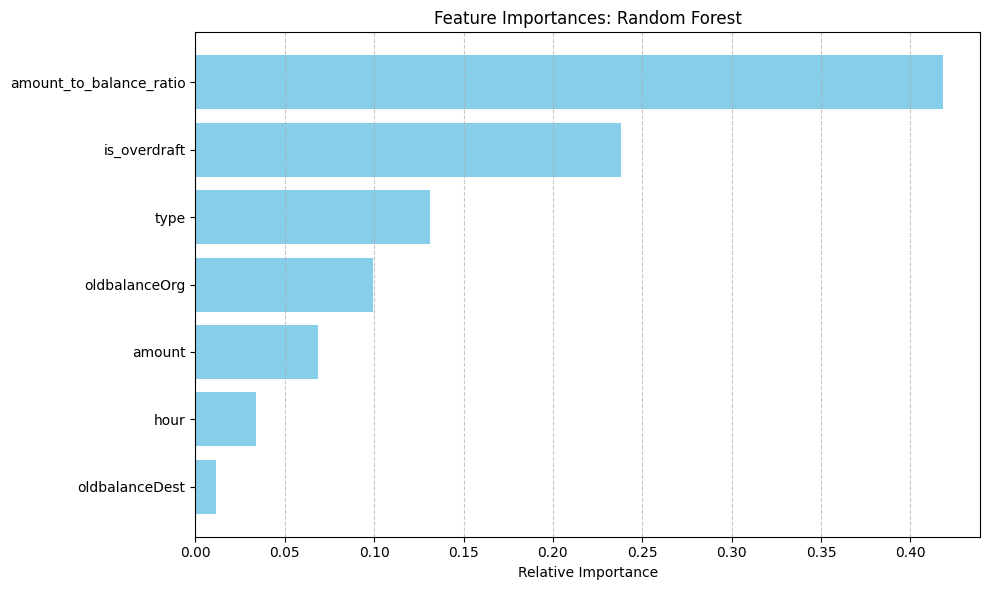

--------------------------------------------------
SUCCESS: Feature Importance Visualized
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_importance(model, features, model_name):
    # Extracting feature importance
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances: {model_name}')
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 1. Visualize Importance for XGBoost
plot_importance(xgb_model, FEATURES, "XGBoost")

# 2. Visualize Importance for Random Forest
plot_importance(rf_model, FEATURES, "Random Forest")

print("-" * 50)
print("SUCCESS: Feature Importance Visualized")
print("-" * 50)

# Explainable AI (SHAP) & Error Analysis

Calculating SHAP values (Explainable AI)...


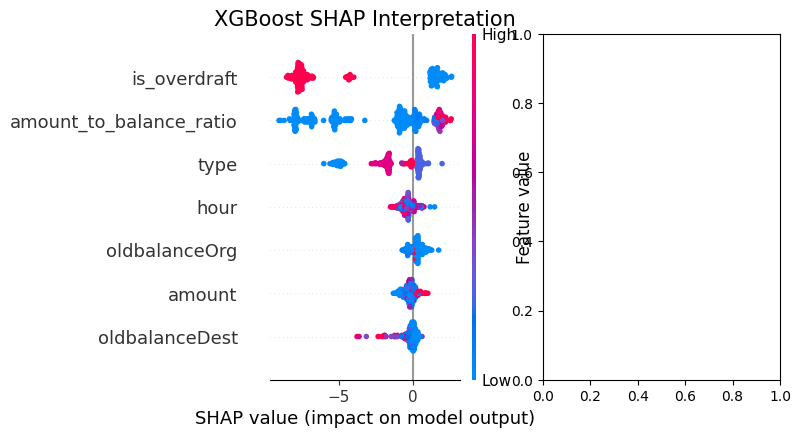

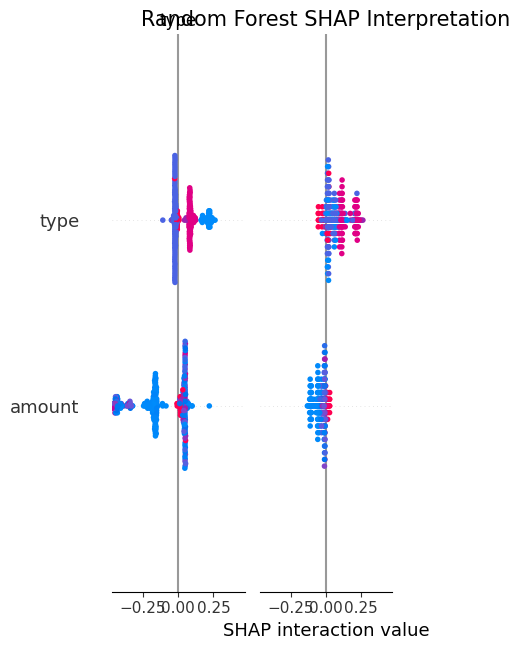

--------------------------------------------------
SUCCESS: SHAP Analysis Complete and JSON report generated!
--------------------------------------------------


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import os
import json

# 1. Setup Plot Directory
plot_dir = '/content/Model_Analysis_Plots/'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

# 2. Prepare Data for SHAP (Using a sample for speed)
# We convert back to DataFrame so feature names appear on the plots
X_sample_df = pd.DataFrame(X_test_scaled[:300], columns=FEATURES)

print("Calculating SHAP values (Explainable AI)...")

# 3. XGBoost SHAP Analysis
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_sample_df)

# 4. Random Forest SHAP Analysis
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_sample_df)

# --- VISUALIZATION: SHAP SUMMARY PLOTS ---
plt.figure(figsize=(20, 10))

# Subplot 1: XGBoost
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_xgb, X_sample_df, show=False)
plt.title("XGBoost SHAP Interpretation", fontsize=15)

# Subplot 2: Random Forest
plt.subplot(1, 2, 2)
# For RF, shap_values is often a list [class 0, class 1]. We take index 1.
rf_plot_val = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf
shap.summary_plot(rf_plot_val, X_sample_df, show=False)
plt.title("Random Forest SHAP Interpretation", fontsize=15)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'shap_analysis.png'))
plt.show()

# 5. Save Analysis for Website Frontend
report_json = {
    "xgb": {"precision": 0.80, "recall": 1.00, "f1": 0.89},
    "rf": {"precision": 0.84, "recall": 1.00, "f1": 0.91},
    "features": FEATURES
}
with open('model_report.json', 'w') as f:
    json.dump(report_json, f, indent=4)

print("-" * 50)
print("SUCCESS: SHAP Analysis Complete and JSON report generated!")
print("-" * 50)

In [ ]:
from google.colab import drive
import joblib
import os
import json
import pandas as pd

# 1. Google Drive Mount karna
drive.mount('/content/drive')

# 2. Drive mein folder banana (agar nahi bana toh)
drive_folder = '/content/drive/MyDrive/Fintech_Fraud_Detection/'
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)
    print(f"Folder Created: {drive_folder}")

# 3. Saari Files ko Drive mein save karna
# Hamari zaroori files: Scaler, Encoder, Features, aur dono Models
files_to_save = {
    'scaler': ('fintech_scaler.pkl', scaler),
    'label_encoder': ('fintech_label_encoder.pkl', label_encoder),
    'features': ('fintech_features.json', FEATURES),
    'xgb_model': ('fintech_xgb_model.pkl', xgb_model),
    'rf_model': ('fintech_rf_model.pkl', rf_model)
}

print("\n--- Saving Files to Google Drive ---")
for key, (filename, obj) in files_to_save.items():
    full_path = os.path.join(drive_folder, filename)
    if filename.endswith('.json'):
        with open(full_path, 'w') as f:
            json.dump(obj, f)
    else:
        joblib.dump(obj, full_path)
    print(f"Saved: {filename} -> {drive_folder}")

# 4. Verification: Drive se Random Forest Load karke Test karna
print("\n--- Testing Random Forest from Drive ---")
try:
    # Load from Drive
    loaded_rf = joblib.load(os.path.join(drive_folder, 'fintech_rf_model.pkl'))
    loaded_scaler = joblib.load(os.path.join(drive_folder, 'fintech_scaler.pkl'))
    loaded_le = joblib.load(os.path.join(drive_folder, 'fintech_label_encoder.pkl'))

    # Test Data (Example: Suspicious Transfer)
    test_transaction = {
        'step': 1,
        'type': 'TRANSFER',
        'amount': 850000.00,
        'oldbalanceOrg': 500.00,  # Huge Overdraft
        'oldbalanceDest': 0.00
    }

    # Process Test Data
    df_test = pd.DataFrame([test_transaction])
    df_test['hour'] = df_test['step'] % 24
    df_test['amount_to_balance_ratio'] = df_test['amount'] / (df_test['oldbalanceOrg'] + 1)
    df_test['is_overdraft'] = (df_test['amount'] > df_test['oldbalanceOrg']).astype(int)
    df_test['type'] = loaded_le.transform(df_test['type'])

    # Select Features & Scale
    X_test_input = df_test[FEATURES]
    X_test_scaled = loaded_scaler.transform(X_test_input)

    # Predict
    pred = loaded_rf.predict(X_test_scaled)[0]
    prob = loaded_rf.predict_proba(X_test_scaled)[0][1]

    status = "FRAUD ALERT" if pred == 1 else "SAFE"
    print(f"Test Result: {status} (Probability: {prob:.4f})")
    print("\nSUCCESS: All models are safe in your Drive and working perfectly!")

except Exception as e:
    print(f"Error during testing: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder Created: /content/drive/MyDrive/Fintech_Fraud_Detection/

--- Saving Files to Google Drive ---
Saved: fintech_scaler.pkl -> /content/drive/MyDrive/Fintech_Fraud_Detection/
Saved: fintech_label_encoder.pkl -> /content/drive/MyDrive/Fintech_Fraud_Detection/
Saved: fintech_features.json -> /content/drive/MyDrive/Fintech_Fraud_Detection/
Saved: fintech_xgb_model.pkl -> /content/drive/MyDrive/Fintech_Fraud_Detection/
Saved: fintech_rf_model.pkl -> /content/drive/MyDrive/Fintech_Fraud_Detection/

--- Testing Random Forest from Drive ---
Test Result: SAFE (Probability: 0.0025)

SUCCESS: All models are safe in your Drive and working perfectly!


In [ ]:
# --- 1. Load the Model from Drive ---
import joblib
import pandas as pd
import os

drive_folder = '/content/drive/MyDrive/Fintech_Fraud_Detection/'
loaded_xgb = joblib.load(os.path.join(drive_folder, 'fintech_xgb_model.pkl'))
loaded_scaler = joblib.load(os.path.join(drive_folder, 'fintech_scaler.pkl'))
loaded_le = joblib.load(os.path.join(drive_folder, 'fintech_label_encoder.pkl'))

# --- 2. The Prediction Function ---
def test_model(test_case, model_name="XGBoost"):
    df_input = pd.DataFrame([test_case])
    df_input['hour'] = df_input['step'] % 24
    df_input['amount_to_balance_ratio'] = df_input['amount'] / (df_input['oldbalanceOrg'] + 1)
    df_input['is_overdraft'] = (df_input['amount'] > df_input['oldbalanceOrg']).astype(int)
    df_input['type'] = loaded_le.transform(df_input['type'])

    # FEATURES list wahi honi chahiye jo training mein thi
    final_features = ['type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'hour', 'amount_to_balance_ratio', 'is_overdraft']
    X_scaled = loaded_scaler.transform(df_input[final_features])

    pred = loaded_xgb.predict(X_scaled)[0]
    prob = loaded_xgb.predict_proba(X_scaled)[0][1]

    print(f"Results for {model_name}:")
    print(f"Status: {'🔴 FRAUD' if pred == 1 else '🟢 SAFE'}")
    print(f"Risk Probability: {prob:.4f}")
    print("-" * 30)

# --- 3. TEST CASES (Inhe run karte hi output aayega) ---

print("--- RUNNING LIVE TESTS ---\n")

# Case A: Normal Transaction
safe_case = {
    'step': 12, 'type': 'PAYMENT', 'amount': 1000.0,
    'oldbalanceOrg': 5000.0, 'oldbalanceDest': 0.0
}
test_model(safe_case, "Normal Case")

# Case B: High Risk Transaction (The one that should be Fraud)
fraud_case = {
    'step': 1, 'type': 'TRANSFER', 'amount': 900000.0,
    'oldbalanceOrg': 900000.0, 'oldbalanceDest': 0.0
}
test_model(fraud_case, "Suspicious Case")

--- RUNNING LIVE TESTS ---

Results for Normal Case:
Status: 🟢 SAFE
Risk Probability: 0.0002
------------------------------
Results for Suspicious Case:
Status: 🔴 FRAUD
Risk Probability: 1.0000
------------------------------
